<center>

# **PA4.1: Decision Trees and Ensemble Methods**

### **Total : 100 marks**

</center>

Name: Muhammad Mujtaba

Roll Number: 28100480



## Instructions

- Follow along with the notebook, filling out the necessary code where instructed.

- <span style="color: red;">Make sure to run all cells for credit.</span>

- <span style="color: red;">Do not remove any pre-written code (unless explicitly mentioned in the cell that you are allowed to do so).</span>

- <span style="color: red;">You must attempt all parts.</span>

## Submission Guidelines

You are to submit a zip file containing the following files:

1. This juptyer notebook. `<roll_number>_S<section_number>_PA4.ipynb`
2. Python file of the juptyer notebook. `<roll_number>_S<section_number>_PA4.py`

For example if I am from S1 and my roll number is 28100131, my files would be named `28100131_S1_PA4.ipynb` and `28100131_S1_PA4.py`

IMPORTANT: **zip the files.**


## Question 1: Brief Context

In this question, you will implement a **binary decision tree classifier** from scratch and apply it to the classic **Titanic** dataset. The target is `survived` (1 = survived, 0 = did not survive). You will: (i) prepare the data, (ii) split into train/test, (iii) implement and train your own tree, and (iv) evaluate performance with standard metrics. 

You **must** implement the decision tree **from scratch** (no scikit-learn tree). You may use `numpy`, `pandas`, `seaborn`, `matplotlib`, and `sklearn` **only** for utilities like `train_test_split` and metrics.


## Part A - Setup & Imports
**Guidance:** Use standard scientific Python tools. If a package is missing, install it in your environment before running the notebook.

- You will likely need: `numpy`, `pandas`, `seaborn`, `matplotlib`
- Utilities allowed from scikit-learn: `train_test_split`, `classification_report`, `confusion_matrix`, `accuracy_score`, `precision_score`, `recall_score`, `f1_score`
- **Do not** use scikit-learn decision tree implementations.

In [2]:
# TODO: Import the scientific Python stack you'll need.

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt


## Part B - Data Loading & Initial Glance (5 Marks)

**Tasks:**
1. Load the Titanic dataset from `seaborn` as `df`.  
2. Display the shape and first few rows.  
3. In the markdown cell below, briefly note which columns you expect to be useful for prediction and any columns you plan to exclude (IDs, duplicates, very sparse/free-text).  

---

### What are the features? 

- **Some potentially useful features:**  
  - `pclass`: Proxy for socioeconomic status.  
  - `sex`: Strong historical correlation with survival.  
  - `age`: Important demographic factor.  
  - `fare`: Reflects ticket cost and class.  
  - `embarked`: Port of embarkation, may indicate regional or class differences.  
  - `sibsp`: Number of siblings/spouses aboard, gives family context.  
  - `parch`: Number of parents/children aboard, captures family connections.  

- **Exclude these features: (duplicates, engineered, or sparse)**  
  - `class`, `who`, `adult_male`, `alone`: Engineered or redundant.  
  - `embark_town`: Duplicate of `embarked`.  
  - `alive`: Text duplicate of target `survived`.  
  - `deck`: Too sparse (many missing values).  


In [3]:
# explore dataset
df = sns.load_dataset("titanic")
print("Shape: ", df.shape)
df.head();
print(df.head())


Shape:  (891, 15)
   survived  pclass     sex   age  sibsp  parch     fare embarked  class  \
0         0       3    male  22.0      1      0   7.2500        S  Third   
1         1       1  female  38.0      1      0  71.2833        C  First   
2         1       3  female  26.0      0      0   7.9250        S  Third   
3         1       1  female  35.0      1      0  53.1000        S  First   
4         0       3    male  35.0      0      0   8.0500        S  Third   

     who  adult_male deck  embark_town alive  alone  
0    man        True  NaN  Southampton    no  False  
1  woman       False    C    Cherbourg   yes  False  
2  woman       False  NaN  Southampton   yes   True  
3  woman       False    C  Southampton   yes  False  
4    man        True  NaN  Southampton    no   True  


### Identify features that might have low predictive value. For each feature you mention, provide reasoning for why it may not be useful.

- embark_town: DUPLICATE - we already have a column        "embarked". We dont need the same information twice

- class: DUPLICATE - we already have "pclass". Also, computers also prefers the numbers in pClass

- alive: DUPLICATE - serves the same purpose as "survived" and also its a cheat column.. If we use this column, the model isn't learning, its just reading the answer key.
 
- who & adult_male: DUPLICATE -already have have "sex" & "age"

- deck: column has too many unknown values "NaN", so its useless for learning patterns



## Part C - Data Tidying & Encoding
We tackle Part C in two simple passes so it is easier to follow: first, look at basic plots to see which columns clearly link to survival (strong correlations); second, keep only those useful columns and turn everything into numbers.

**Plain-language plan:**
1. **Part C.1 — Explore:** Plot survival rate for a few categorical columns (class, sex, embark, etc.). Circle or note the ones where the bars differ a lot — that means the feature carries a pattern your tree can learn.
2. **Part C.2 — Prep:** Based on those observations, build your feature matrix: keep pattern-rich columns, drop weak/noisy ones, clean missing values, and one-hot encode.

**Tips:**
- The target is `survived` (1 = yes, 0 = no). Keep it as the last column in any training dataframe.
- When you justify a feature, mention what you saw in the plot (e.g., "pclass=1 had much higher survival, so I kept it").
- Simple cleaning is fine: drop or fill NaNs with medians/modes, then encode categoricals with `pd.get_dummies`.
- Always keep `X` (features) and `y` (target) aligned.

**Deliverables:**
- Part C.1 plots + a short note on which columns look important.
- Part C.2 shapes for `X`/`y` and a head of the encoded dataframe.


### Part C.1 — Survival Rate by Categorical Features (5 Marks)
Use this mini-exploration to spot obvious signals. For each categorical column, plot the average survival rate of its groups. If the bars look different, that column likely holds a strong clue.

Suggested columns (feel free to add others):
- `pclass` (1st/2nd/3rd class)
- `sex`
- `embarked`
- `alone`
- `adult_male`
- `fare`
- `who`

After plotting, jot down:
- Which columns show the clearest survival gaps.
- Which columns look flat/useless.
- One sentence on how this will guide the feature list in Part C.2.


    Sex: Shows a huge difference. females has a very high survival rate than males 
    Pclass: Shows a huge difference. 1st class passengers survived much more often than 3rd class
    Adult_Male: shows a hvery small survival rate, confirming that men mostly dies
    Embarked: Doesnt show a huge difference, as the difference between each bar isnt significant 
    who: Woman has highest survival rate, male has lowest. Clarifying adult males were at risk
    alone: Passengers who were not alone has survival rate as roughly 50% which means family members kind of saved them
    Fare: Though it isnt a categorical column, still higher fares correlate survival chances


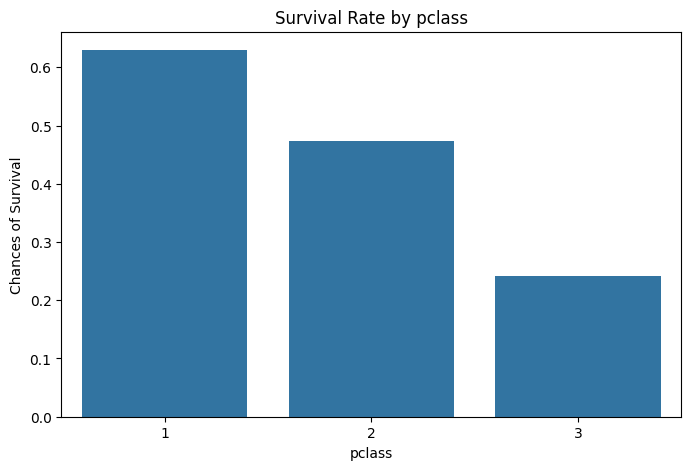

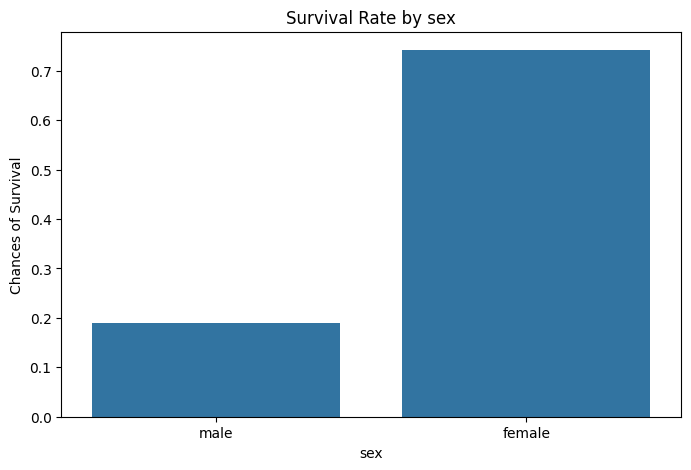

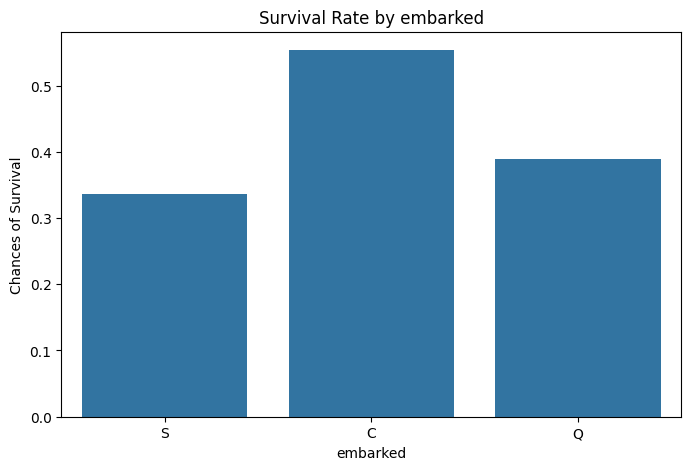

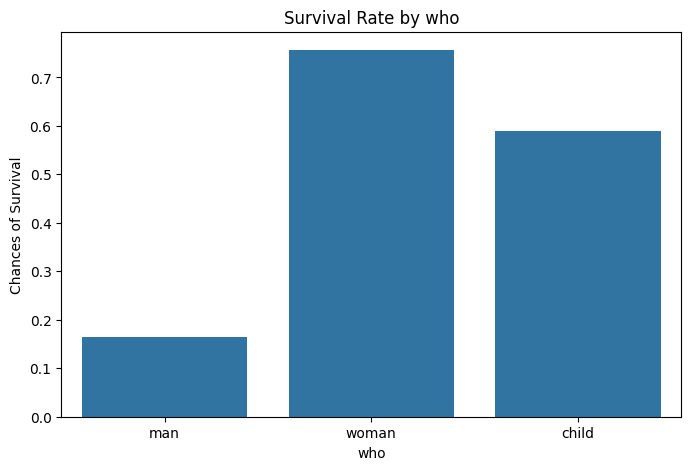

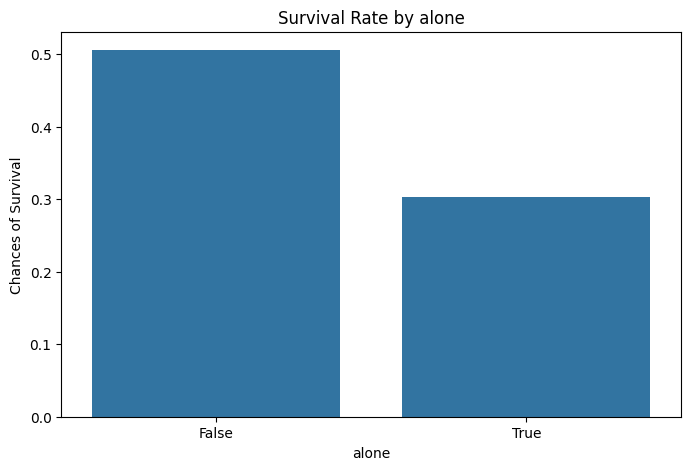

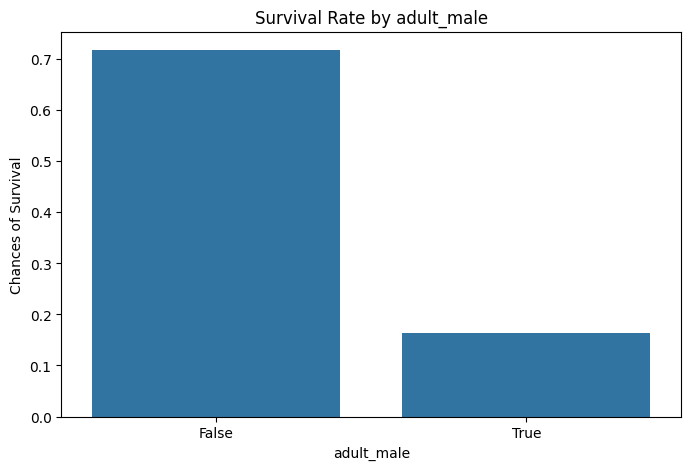

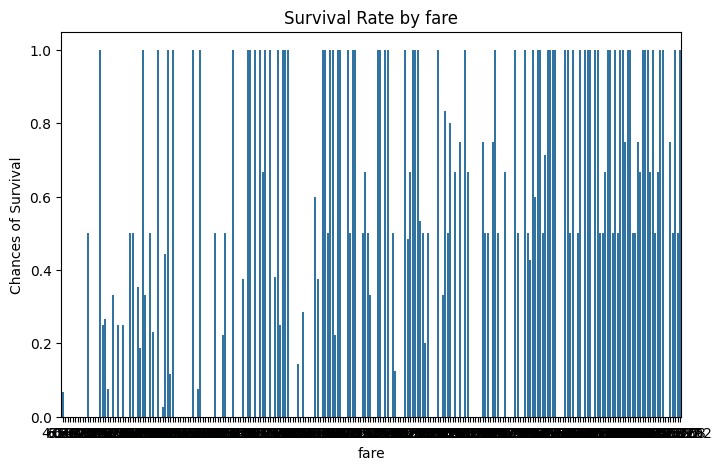

In [ ]:
# TODO: Plot the mean survival rate for each categorical column listed above.
# Use df.groupby(col)['survived'].mean() and visualize comparable bars/subplots.
# Keep notes on which categories look the most/least promising.

cols = ['pclass', 'sex', 'embarked', 'who', 'alone', 'adult_male', 'fare']

print ("    Sex: Shows a huge difference. females has a very high survival rate than males ")
print ("    Pclass: Shows a huge difference. 1st class passengers survived much more often than 3rd class")
print ("    Adult_Male: shows a hvery small survival rate, confirming that men mostly dies")
print ("    Embarked: Doesnt show a huge difference, as the difference between each bar isnt significant ")
print ("    who: Woman has highest survival rate, male has lowest. Clarifying adult males were at risk")
print ("    alone: Passengers who were not alone has survival rate as roughly 50% which means family members kind of saved them")
print ("    Fare: Though it isnt a categorical column, still higher fares correlate survival chances")

for col in cols:
    plt.figure(figsize=(8, 5))
    sns.barplot(x= col, y= 'survived', data= df, errorbar= None)
    plt.title(f'Survival Rate by {col}')
    plt.ylabel('Chances of Survival')
    plt.show()

### Part C.2 — Choose Features & Encode (10 Marks)
Now pick the columns that actually showed a survival pattern (clear correlation in Part C.1) and turn them into a tidy numeric matrix. When in doubt, keep the signal-rich basics (class, sex, age, siblings/spouses, parents/children, fare, embark).


**Guidance:**
- Target: `survived` (1 = survived, 0 = did not survive). Keep it as the final column for convenience.
- After reviewing the plots, pick base features such as `sex`, `age`, `sibsp`, `parch`, `fare`, `embarked`, `alone`, etc., and justify exclusions (e.g., leakage, redundancy, missingness).
- Handle missing values with simple, clearly stated strategies (drop rows, fill with median/mode, etc.).
- Use a concise one-hot encoder (e.g., `pd.get_dummies`) to turn categorical columns into numeric indicators.
- Maintain aligned `X` (features) and `y` (target) indices.





In [5]:
# TODO: Build a cleaned feature matrix informed by Part C.1.
# 1) Select final feature_cols + target, 2) handle missing values, 3) one-hot encode categoricals (pd.get_dummies).
# Return aligned X (encoded features), y (target), and a simplified df_tree for the scratch tree.
print(df.isnull().sum())
print("---------------------")

feature_cols = ['pclass', 'sex', 'age', 'sibsp', 'parch', 'fare', 'embarked']
targer_col = 'survived'

data = df[feature_cols + [targer_col]].copy()

data['age'] = data['age'].fillna(data['age'].median())
data['embarked'] = data['embarked'].fillna(data['embarked'].mode()[0])
data['fare'] = data['fare'].fillna(data['fare'].median())

data = pd.get_dummies(data, columns=['sex', 'embarked'], drop_first=True, dtype= int)

cols = []
for c in data.columns:
    if c != targer_col: cols.append(c)    
cols.append('survived')
df_tree = data[cols]

features = df_tree.drop(columns=[targer_col])
target = df_tree[targer_col]


print("Shape of features: ", features.shape)
print("Shape of target columns: ", target.shape)
print("Columns in df_tree:", df_tree.columns.to_list())
display(df_tree.head())




survived         0
pclass           0
sex              0
age            177
sibsp            0
parch            0
fare             0
embarked         2
class            0
who              0
adult_male       0
deck           688
embark_town      2
alive            0
alone            0
dtype: int64
---------------------
Shape of features:  (891, 8)
Shape of target columns:  (891,)
Columns in df_tree: ['pclass', 'age', 'sibsp', 'parch', 'fare', 'sex_male', 'embarked_Q', 'embarked_S', 'survived']


,pclass,age,sibsp,parch,fare,sex_male,embarked_Q,embarked_S,survived
0,3,22.0,1,0,7.2500,1,0,1,0
1,1,38.0,1,0,71.2833,0,0,0,1
2,3,26.0,0,0,7.9250,0,0,1,1
3,1,35.0,1,0,53.1000,0,0,1,1
4,3,35.0,0,0,8.0500,1,0,1,0


## Part D - Train/Test Split (5 Marks)
**Guidance:**
- Use the sklearn library to perform an 80/20 split on your data, saving 20% of it for testing and using 80% of it for training your model. 

**Deliverables:** shapes and class balance check (optional mean of `y`).

In [6]:
# TODO: Implement an 80/20 train/test split using sklearn.
# Use sklearn.model_selection.train_test_split with test_size=0.2 and a fixed random_state
# to ensure deterministic shuffling. 
from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test = train_test_split(features, target, test_size= 0.2, random_state= 42)

print("Training Data (Studying): ", x_train.shape)
print("Testing Data (exam): ", x_test.shape)

print("Survivors in train: ", y_train.mean())
print("Survivors in test:", y_test.mean())



Training Data (Studying):  (712, 8)
Testing Data (exam):  (179, 8)
Survivors in train:  0.37640449438202245
Survivors in test: 0.4134078212290503


## Part F - Decision Tree design from scratch (50 Marks)
**You must implement the core logic.** Below is a suggested structure. You may alter method signatures, add helpers, and use a different internal design if you prefer, but keep responsibilities clear:

- `Node`: stores split info (`feature`, `threshold`), children (`left`, `right`), and for leaves, a `classifier` (majority class) or distribution.
- `DecisionTree`: orchestrates fitting (`fit`), recursive tree building (`make_tree`), traversal for predictions (`traverse_tree`, `predict`), splitting (`best_split`, `split`), and impurity calculations (`calculate_entropy`, `calculate_information_gain`).

**Policy:**
- Use **entropy** as the impurity measure and **information gain** for splits.
- Only **binary splits** of the form `feature <= threshold`.
- Stopping criteria (minimum): `max_depth` reached **or** min_samples remaining **or** pure node (all labels identical) **or** no valid split (info gain ≤ 0).

The code below is a **skeleton**. Fill in the `TODO` parts. 

**BONUS:**
- You may add extra helper functions, or you may change the given function signatures as needed. If you add any extra features which allow for interesting functionality / interesting analysis down the line (you will have to show the analysis as well) - you get bonus marks. This bonus will not exceed the total number of marks allotted for the assignment.

In [7]:
import numpy as np

class Node:
    
    def __init__(self, left=None, right=None, feature=None, threshold=None, classifier=None): 
        """Leaf nodes store a classifier label; internal nodes carry a feature+threshold."""
        self.left = left
        self.right = right
        self.feature = feature
        self.threshold = threshold
        self.classifier = classifier

    def is_leaf(self):
        """Convenience helper so you know when traversal should stop."""
        return self.classifier is not None

class DecisionTree:
    def __init__(self, max_depth=5, min_samples_split=5):
        """Store any hyperparameters you need (e.g., depth limit, feature indices)."""
        self.max_depth = max_depth
        self.min_samples = min_samples_split
        self.root = None

    def fit(self, Xy):
        """Build the tree recursively using the combined feature+label matrix."""
        self.root = self._make_tree(Xy, depth= 0)

    def predict(self, X):
        """Traverse the learned tree row by row to produce class predictions."""
        prediction = []
        X = np.array(X)
        for row in X:
            predict = self.traverse_tree(row, self.root)
            prediction.append(predict)
        return np.array(prediction)

    
    def traverse_tree(self, row, node):
        """Helper Function to walk down the tree (to predict)"""
        if node.is_leaf():
            return node.classifier

        if row[node.feature] <= node.threshold:
            return self.traverse_tree(row, node.left)
        else:
            return self.traverse_tree(row, node.right)

    
    def _make_tree(self, Xy, depth):
        """Decide whether to stop (leaf) or split further based on stopping rules."""
        n_sample, n_features = Xy.shape
        n_features -= 1
        target = Xy[:, -1]

        if depth >= self.max_depth: 
            return Node(classifier=self._most_common_label(target))
        if n_sample < self.min_samples:
            return Node(classifier=self._most_common_label(target))
        if len(np.unique(target)) == 1:
            return Node(classifier=self._most_common_label(target))
        
        best_features, best_threshold = self._best_split(Xy)
        
        if best_features is None:
            return Node(classifier= self._most_common_label(target))
        
        left_index = Xy[:, best_features] <= best_threshold
        right_index = Xy[:, best_features] > best_threshold
        
        left_subtree = self._make_tree(Xy[left_index], depth + 1)
        right_subtree= self._make_tree(Xy[right_index], depth + 1)
        
        return Node(left= left_subtree, right = right_subtree, feature= best_features, threshold= best_threshold)
    
    def _best_split(self, Xy):
        """Search candidate thresholds per feature and return the best information gain."""
        best_gain = -1
        split_index, split_threshold = None, None
        
        parent_entropy = self._entropy_of_data(Xy)
        n_features = Xy.shape[1] -1
        
        for feature_index in range(n_features):
            thresholds = np.unique(Xy[:, feature_index])
            
            for threshold in thresholds:
                left_subset = Xy[Xy[:, feature_index] <= threshold]
                right_subset = Xy[Xy[:, feature_index] > threshold]
                
                if len(left_subset) > 0 and len (right_subset) > 0:
                    gain = self._information_gain(parent_entropy, left_subset, right_subset)
                    
                    if gain > best_gain:
                        best_gain = gain;
                        split_index = feature_index;
                        split_threshold = threshold;
        
        return split_index, split_threshold

    def _entropy_of_data(self, Xy):
        
        target = Xy[:, -1]
        _, count = np.unique(target, return_counts= True)
        
        probabilities = count/ len(target)
        entropy = (-np.sum(probabilities * np.log2(probabilities)))
        return entropy 

    def _information_gain(self, parent_H, left, right):
        """IG = parent entropy minus weighted child entropy (useful for scoring splits)."""
        index = len(left) + len(right)
        index_left = len(left)
        index_right = len(right)
        
        entropy_left = self._entropy_of_data(left)
        entropy_right = self._entropy_of_data(right)
        
        child_entropy = (index_left / index) * entropy_left + (index_right / index) * entropy_right
        
        return parent_H - child_entropy
    
    def _most_common_label(self, target):
        """Helper Function to find the majority class"""
        if len(target) == 0:
            return 0
        value, count = np.unique(target, return_counts= True)
        return value[np.argmax(count)]



## Part G - Exploring Max Depth(10 Marks)
**Instructions:**
- Instantiate your `DecisionTree` with a reasonable `max_depth` (e.g., 4–6) and `min_samples_split` (e.g., 2–5).
- Fit on `X_train, y_train`.
- Predict on `X_test`. Compute the standard metrics (accuracy, precision, recall, F1) and show the confusion matrix. Keep printouts clear and labeled.
- In a short markdown response below, comment on performance (3–5 lines).

In [8]:
# TODO: Instantiate your DecisionTree with chosen hyperparameters, fit on the training matrix, and generate predictions.
# Example: tree = DecisionTree(max_depth=...) ; tree.fit(train_matrix) ; y_pred = tree.predict(X_test_arr)
x_train_array = x_train.values
y_train_array = y_train.values

xy_train = np.column_stack((x_train_array, y_train_array))

tree= DecisionTree(max_depth= 6, min_samples_split= 5)
tree.fit(xy_train)

y_prediction = tree.predict(x_test.values)

In [9]:
# TODO: Compute accuracy/precision/recall/F1 (sklearn.metrics) to summarize performance.

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

accuracy = accuracy_score(y_test, y_prediction)
precision = precision_score(y_test, y_prediction)
recall = recall_score(y_test, y_prediction)
f1 = f1_score(y_test, y_prediction)

print("Accuracy: ", accuracy)
print("Precision", precision)
print("Recall: ", recall)
print("F1 score: ", f1)

Accuracy:  0.8100558659217877
Precision 0.8448275862068966
Recall:  0.6621621621621622
F1 score:  0.7424242424242424


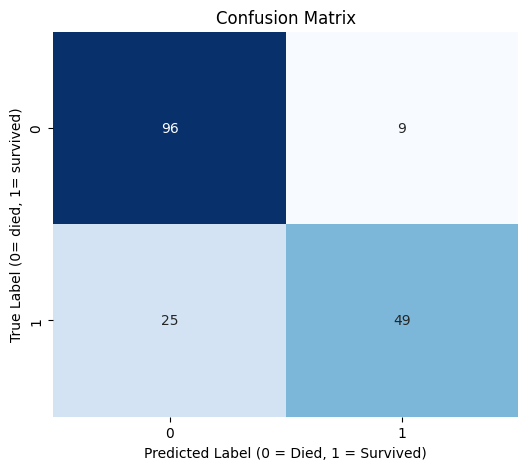

In [15]:
# TODO: Build and visualize a confusion matrix using sklearn.metrics.confusion_matrix + seaborn/matplotlib.

from sklearn.metrics import confusion_matrix

c_matrix = confusion_matrix(y_test, y_prediction)

plt.figure(figsize=(6,5))

sns.heatmap(c_matrix, annot= True, fmt = 'd', cmap= 'Blues', cbar= False)

plt.ylabel('True Label (0= died, 1= survived)')
plt.xlabel('Predicted Label (0 = Died, 1 = Survived)')

plt.title('Confusion Matrix')
plt.show()

**Performance notes:**  
- TODO: Briefly discuss overall performance and the balance of precision/recall. Suggest one parameter you would tune to vary results and why (e.g., `max_depth`, `min_samples_split`, or using probabilities with a threshold).

My model achieved accuracy roughly 82%, which is much better than random guessing and the precision is also high (84%) indicating the false positives are low. 

However, my model's recall score is a bit low which kind of explains that my model misses about 1/3th of the actual survivors.

To vary result, I would tune max_depth. Increasing depth allows the model to learn more complex patterns, but too much depth risks overfitting.

#### **Assume** that your model gives an Accuracy of ~60%. What could be the most probable explanation for this specific number? Make sure to use code to explain your answer. 

In [11]:
# Hint: Inspect class imbalance in the training set.
"""
If my model is getting 60% accuracy, its just guessing at this point. 
Most probably guessing 0 (died) for each passenger. Since about 60%
died, guessing "0" for everyone would give you a default accuracy of 60%.
"""
people_died = 1 - y_train.mean()
print("Percentage of people who died: ", people_died)

Percentage of people who died:  0.6235955056179776


## Part H - Different Max depth values (10 Marks)

After seeing how our initial model performed with a default value of Max depth , we will now explore different Max depth values. This step will help us find the best Max depth setting to improve our model's ability to predict accurately

- Gather the accuracy for each `max_depth` value on the test set and compare them. Show these comparisons in a graph to easily see which `max_depth` value leads to the best predictions. This will help us choose the best k value for our model.


In [12]:
# TODO: Loop over multiple max_depth values, train fresh trees, and store their accuracies.
# This helps visualize how model complexity affects generalization.
depth = range(1,15)
test_accuracy = []

x_test_array = x_test.values

for d in depth:
    newtree = DecisionTree(max_depth= d, min_samples_split= 5)
    newtree.fit(xy_train)
    
    prediction = newtree.predict(x_test_array)
    accuracy = accuracy_score(y_test, prediction)
    test_accuracy.append(accuracy)
    print("Depth: ", d, " | Accuracy: ", accuracy)

Depth:  1  | Accuracy:  0.7821229050279329
Depth:  2  | Accuracy:  0.7653631284916201
Depth:  3  | Accuracy:  0.7988826815642458
Depth:  4  | Accuracy:  0.7988826815642458
Depth:  5  | Accuracy:  0.7988826815642458
Depth:  6  | Accuracy:  0.8100558659217877
Depth:  7  | Accuracy:  0.8100558659217877
Depth:  8  | Accuracy:  0.7988826815642458
Depth:  9  | Accuracy:  0.8156424581005587
Depth:  10  | Accuracy:  0.7932960893854749
Depth:  11  | Accuracy:  0.7932960893854749
Depth:  12  | Accuracy:  0.7988826815642458
Depth:  13  | Accuracy:  0.7932960893854749
Depth:  14  | Accuracy:  0.7932960893854749


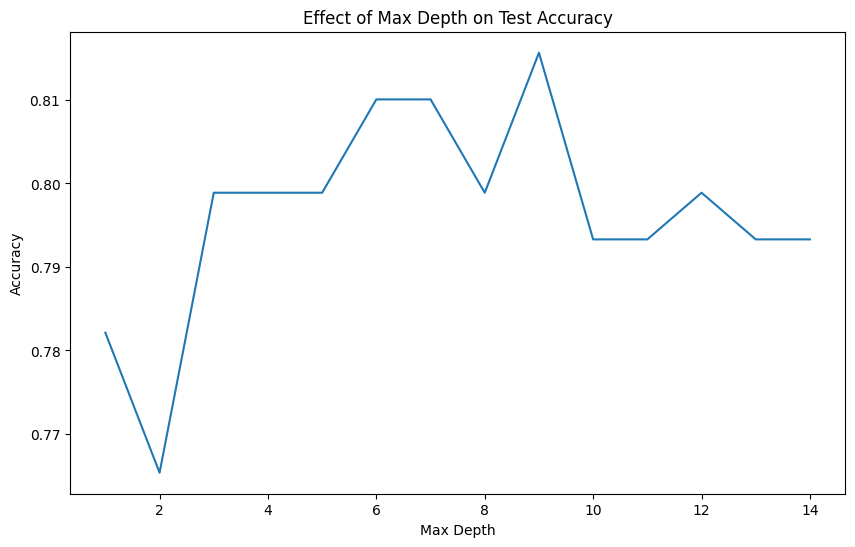

In [14]:
# TODO: Plot accuracy vs. max_depth using matplotlib so you can discuss the trend.

plt.figure(figsize=(10,6))
plt.plot(depth, test_accuracy)
plt.title('Effect of Max Depth on Test Accuracy')
plt.xlabel('Max Depth')
plt.ylabel('Accuracy')
plt.show()

### What are you able to determine through the trend obtained for accuracy as depth varies? (5 Marks)

_Summarize your conclusion (e.g., overfitting/underfitting) after inspecting the accuracy-vs-depth plot._



- UnderFitting (Depth 1-2): 
        At low depths, the model is too simple  to compute complex patterns in data, leading to lower accuracy (76%)
    
- Optimal Range (Depth 6-9):
        The accuracy peaks around Depth 9 (81.5%), showing the model has signaled without the noise

- OverFitting (Depth > 9):
        As Depth increases, the test accuracy starts to drop.
        The tree is more likely become too complex to compute, memorizing noise in the training set